In [34]:
import json
import matplotlib.pyplot as plt


In [35]:
BASE = '../builds/1000train_300val_200test/'
files_path = [
    '1_scenario-3cnn_2bilstm',
    '2_scenario-4cnn_2bilstm',
    '3_scenario-5cnn_2bilstm',
    '4_scenario-6cnn_2bilstm',
    '5_scenario-7cnn_2bilstm',
]
# files_path = [
#     '6_scenario-5cnn_1bilstm',
#     '3_scenario-5cnn_2bilstm',
#     '8_scenario-5cnn_3bilstm',
# ]

def extract_model_name(file_path):
    ''' Example: "1_scenario-3cnn_2bilstm" -> "3C-2B" '''
    arch = file_path.split('-')[-1]
    layers = arch.split('_')
    return f"{layers[0][0]}C-{layers[1][0]}B"

all_train_data = {}
all_test_data = {}

for path in files_path:
    with open(f"{BASE}{path}/train_log.json", 'r') as f:
        data = json.load(f)
        key = extract_model_name(path)
        all_train_data[key] = data['epochs']

    with open(f"{BASE}{path}/test_results.json", 'r') as f:
        data = json.load(f)
        key = extract_model_name(path)
        all_test_data[key] = data['details']

print("Train Data Keys:", all_train_data.keys())
print("Test Data Keys:", all_test_data.keys())

Train Data Keys: dict_keys(['3C-2B', '4C-2B', '5C-2B', '6C-2B', '7C-2B'])
Test Data Keys: dict_keys(['3C-2B', '4C-2B', '5C-2B', '6C-2B', '7C-2B'])


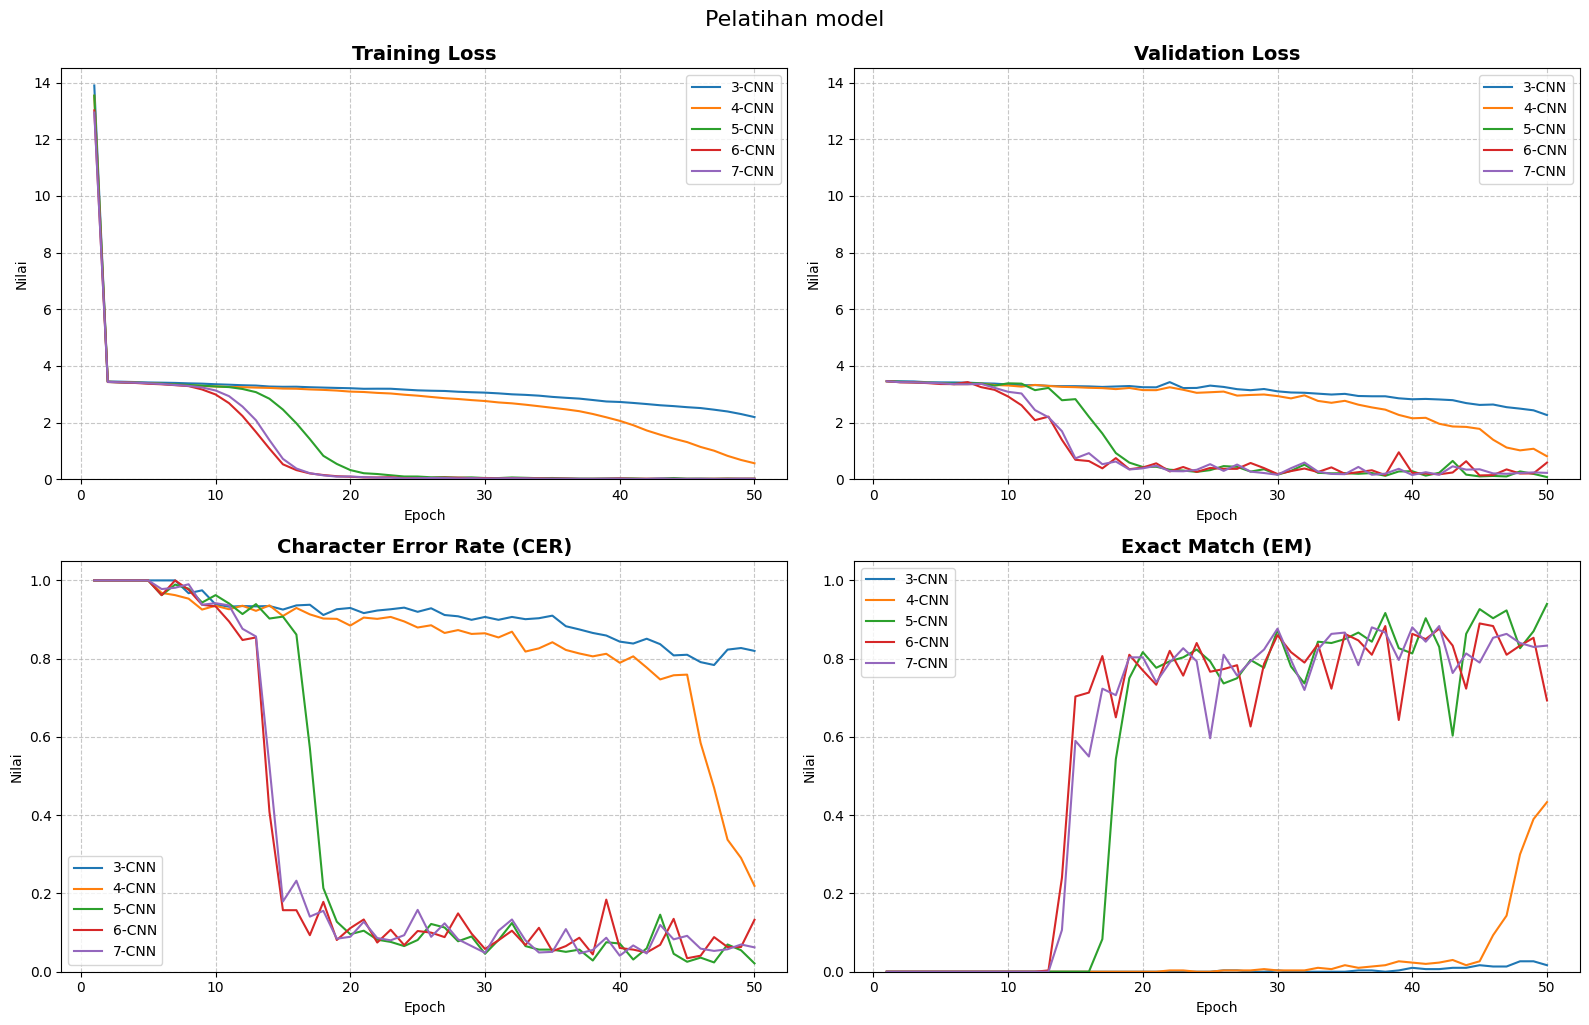

In [36]:
metrics = ['train_loss', 'val_loss', 'cer', 'em']
titles = ['Training Loss', 'Validation Loss', 'Character Error Rate (CER)', 'Exact Match (EM)']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    for model_name, epochs_data in all_train_data.items():
        name = model_name[0] + "-CNN"

        sorted_epochs = sorted(epochs_data, key=lambda x: x['epoch'])
        epochs = [d['epoch'] for d in sorted_epochs]
        values = [d[metric] for d in sorted_epochs]

        axes[i].plot(epochs, values, label=name)

    # set title dan label
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Nilai')
    axes[i].grid(True, linestyle='--', alpha=0.7)
    axes[i].legend()

    # atur batas Y
    if metric in ['train_loss', 'val_loss']:
        axes[i].set_ylim(0, 14.5)
    else:  # CER & EM
        axes[i].set_ylim(0, 1.05)

plt.tight_layout()
plt.suptitle('Pelatihan model', fontsize=16, y=1.02)
plt.show()